## Importing library that are required for doing this project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing  import OrdinalEncoder,OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score,classification_report
from sklearn.pipeline import Pipeline
import pickle

In [2]:
df=pd.read_csv('loan_approval.csv')

## Understanding Data

In [3]:
df.sample(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
2972,2973,2,Graduate,No,4900000,18500000,8,492,12900000,5000000,10200000,5800000,Rejected
2197,2198,4,Graduate,Yes,9600000,19900000,6,319,3200000,16500000,28100000,6600000,Rejected
3462,3463,0,Graduate,No,6500000,20200000,16,842,8300000,12200000,14300000,9600000,Approved
3168,3169,5,Not Graduate,No,2400000,7500000,12,357,2600000,2900000,6100000,1300000,Rejected
1682,1683,1,Not Graduate,Yes,4000000,9400000,8,509,1000000,4100000,10800000,5500000,Rejected


In [4]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


## Cleaning data 

## Removing the leading and tailing space from the columns,sometimes it contain leading and tailing and which create problem like column not found in given dataset.

In [8]:
df.columns=df.columns.str.strip()

## Droping the loan_id column,it may not have affect on target column

In [9]:
df=df.drop(columns='loan_id',axis=1)

## Currenlty in the dataset we are not seeing unclean data,now we are ready to perform EDA,during EDA if we observe any unclean data  or outlier dataa we will perform cleaning and handling outlier  duirng EDA process.

## Univariate Analysis

## no_of_dependents column

In [10]:
result=df['no_of_dependents'].value_counts().sort_values()
result

no_of_dependents
5    673
1    697
2    708
0    712
3    727
4    752
Name: count, dtype: int64

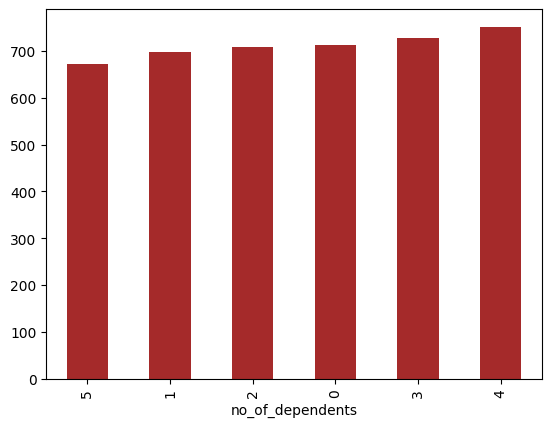

In [11]:
result.plot(kind='bar',color='brown')
plt.show()

<Axes: ylabel='count'>

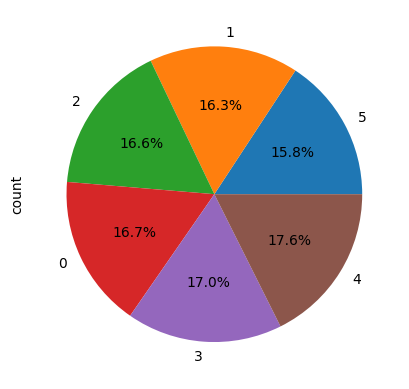

In [12]:
result.plot(kind='pie',autopct='%1.1f%%')

## Insight:
* The number of dependents for applicants ranges strictly from a minimum of $0$ to a maximum of $5$.
*  Applicants with $4$ dependents form the largest segment in the dataset with $752$ observations.
* Although $4$ dependents is the most frequent category, the distribution across all levels ($0$ to $5$) is remarkably well-balanced and uniform, with each category containing between $673$ and $752$ applicants. There is no severe skewness or heavy concentration in any single group.Further we will perform bivariate analysis whether particular this column will influence target column or not.

## Education Column analysis

In [13]:
result=df['education'].value_counts().reset_index(name='Total_Number')
result

,education,Total_Number
0,Graduate,2144
1,Not Graduate,2125


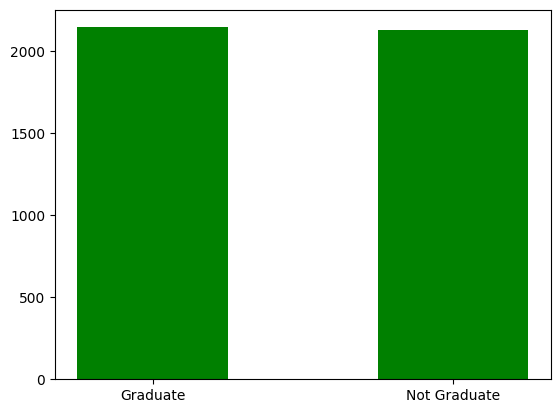

In [14]:
plt.bar(result['education'],result["Total_Number"],color='green',width=0.5)
plt.show()

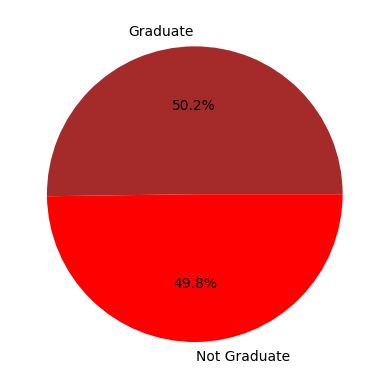

In [15]:
plt.pie(result['Total_Number'],labels=result['education'],autopct='%1.1f%%',colors=['brown','red'])
plt.show()

## Insihgt:
* The applicants for loan had only two category in a education column.
* The data is like uniform distribution on both category of education column.
* We will perform bivariate analysis whether education column will influence on target column or not.

## self_employed column analysis

In [16]:
result=df['self_employed'].value_counts().reset_index(name='Total_Number')
result

,self_employed,Total_Number
0,Yes,2150
1,No,2119


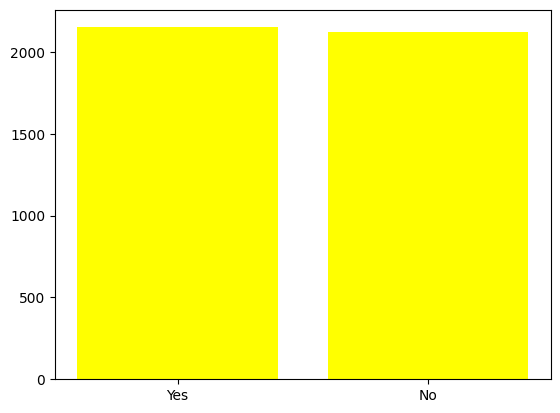

In [17]:
plt.bar(result['self_employed'],result['Total_Number'],color='yellow')
plt.show()

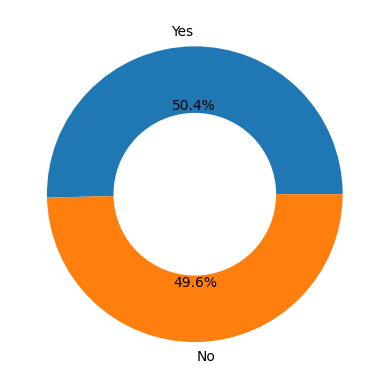

In [18]:
plt.pie(result['Total_Number'],labels=result['self_employed'],autopct='%1.1f%%',wedgeprops={'width': 0.45})
plt.show()

## Insight:
* The self_employed column contains only binary categories {Yes, No} with a uniform distribution.
* Since the distribution is balanced, the variable is not biased toward one category.
* Further analysis is required to identify whether it influenze the target column or not.


## loan_term column analysis

In [19]:
result=df['loan_term'].value_counts()
result

loan_term
6     490
12    456
4     447
10    436
18    422
16    412
20    411
14    405
2     404
8     386
Name: count, dtype: int64

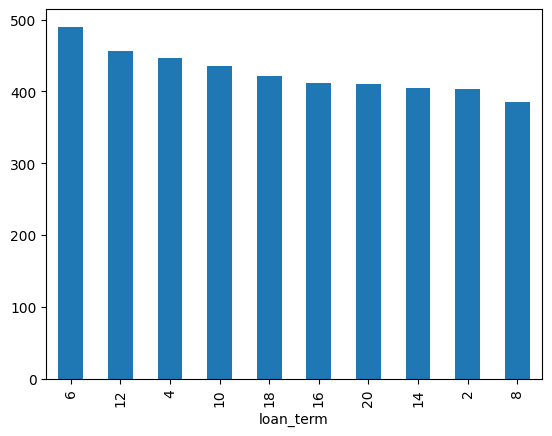

In [20]:
result.plot(kind='bar')
plt.show()

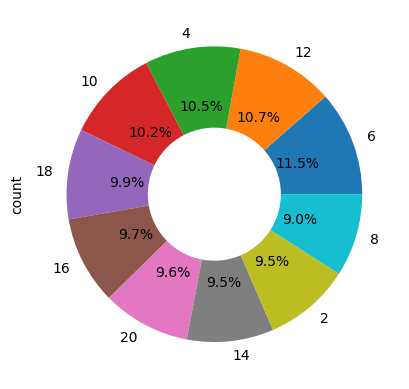

In [21]:
result.plot(kind='pie',autopct='%1.1f%%',wedgeprops={'width':0.55})
plt.show()

## Insight:
* The category value  in loan_term column is from 2 to 14 years or unit.
* Each category value in loan_term is likely equally distributed  with **(9%-10.5%)** .
* Further bivariate analysis is required to identify whether it influence target column or not.

## Analyzing all numberical column at once

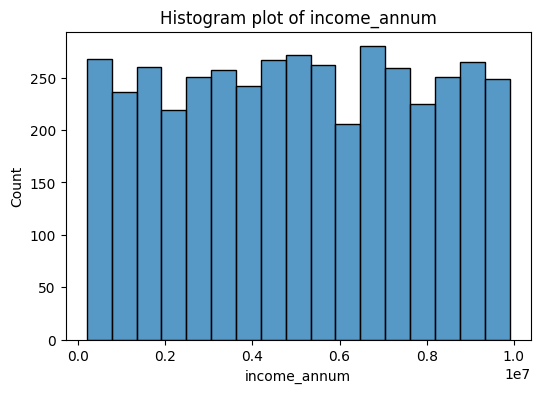

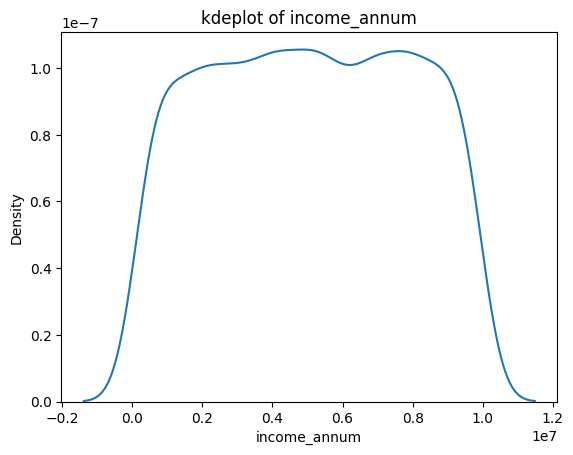

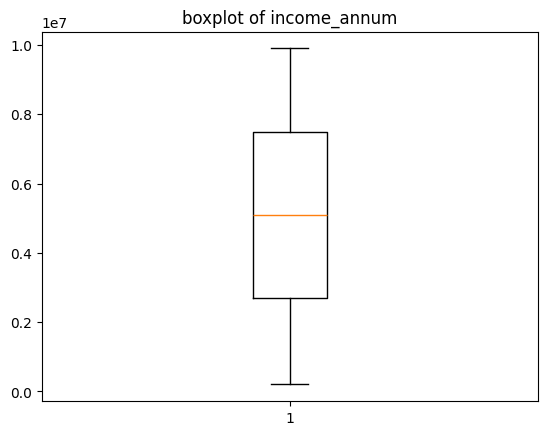

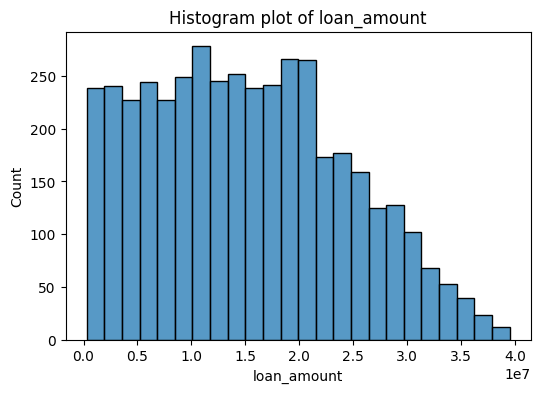

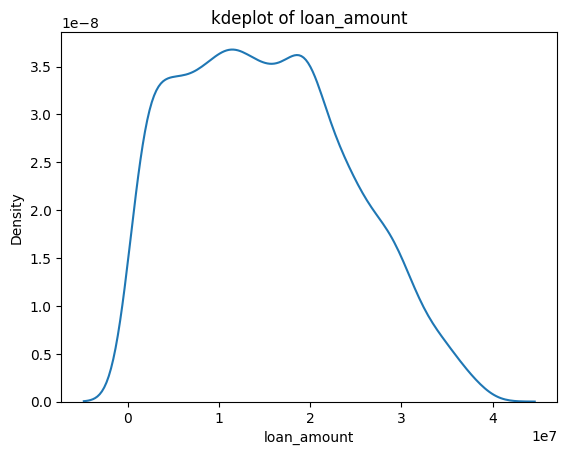

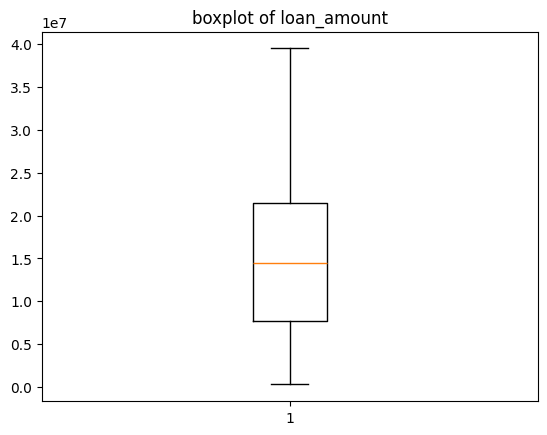

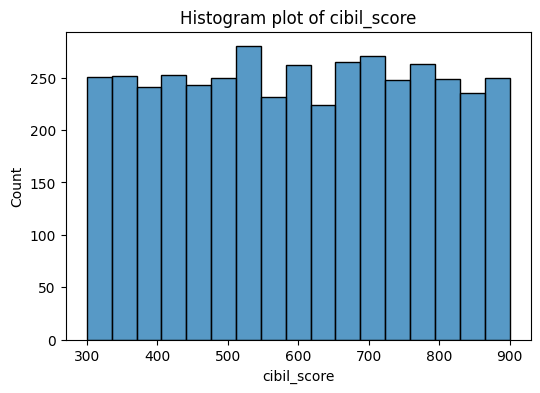

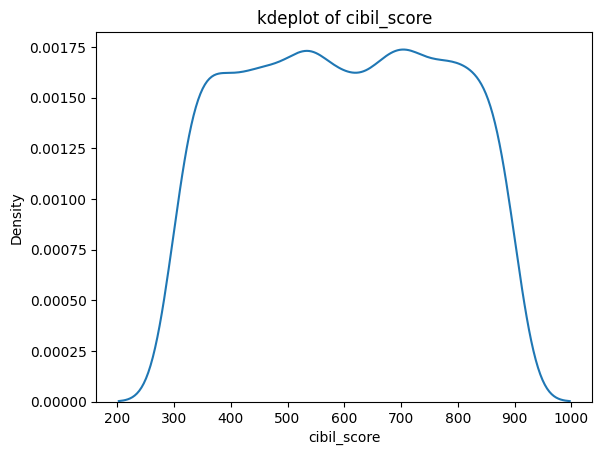

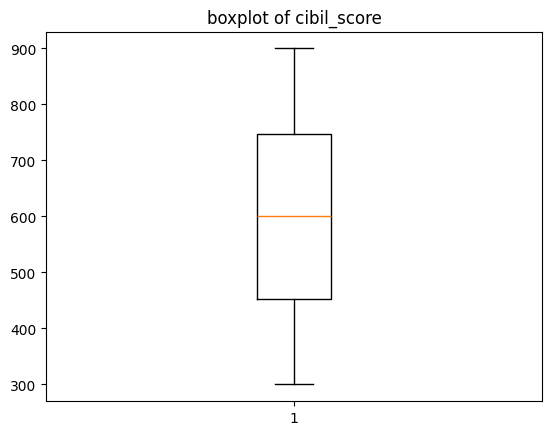

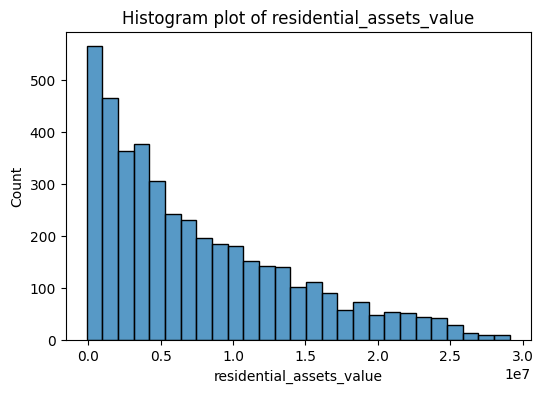

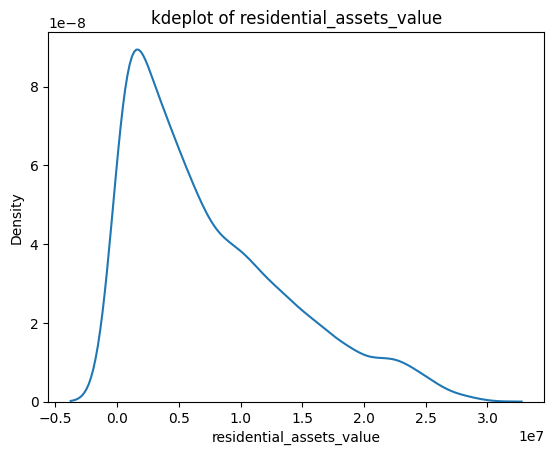

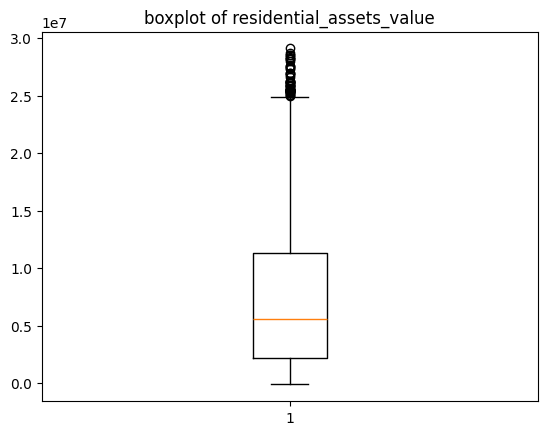

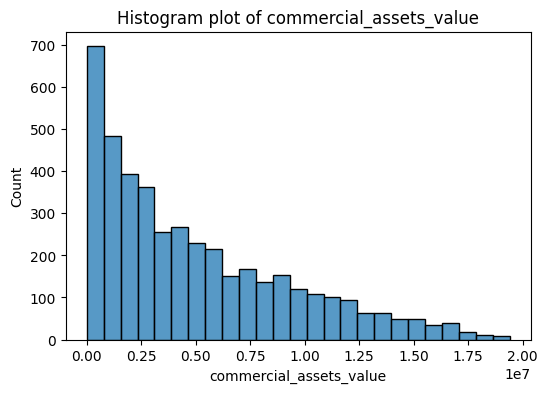

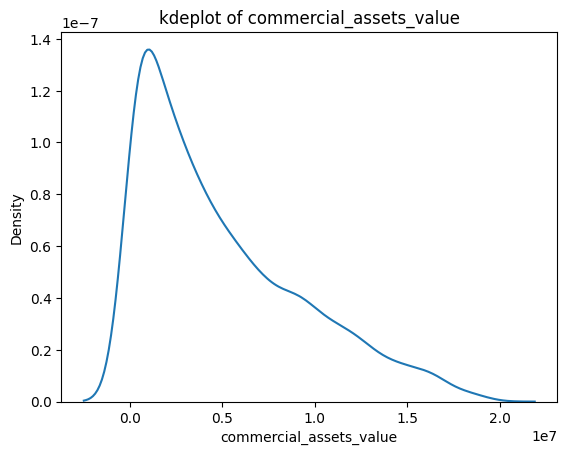

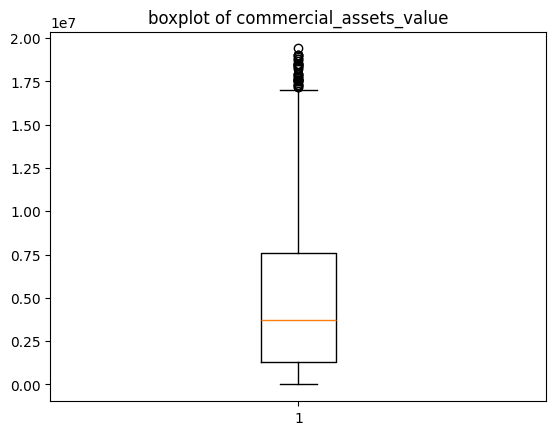

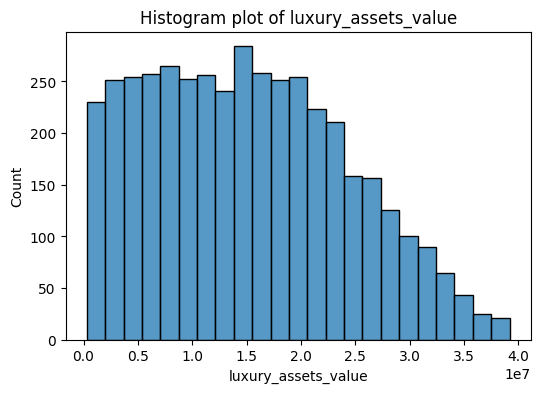

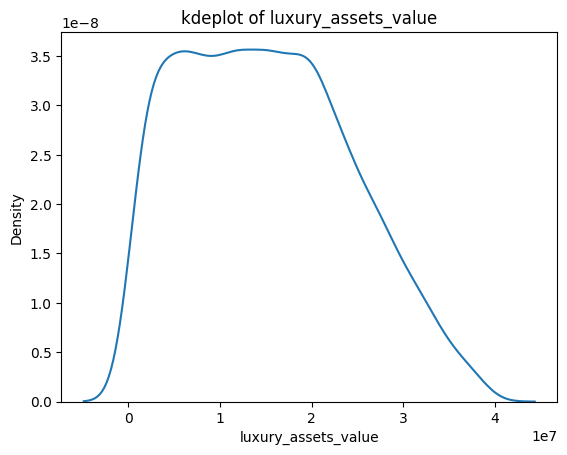

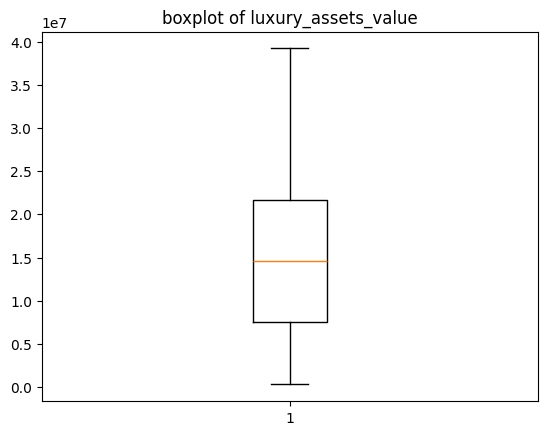

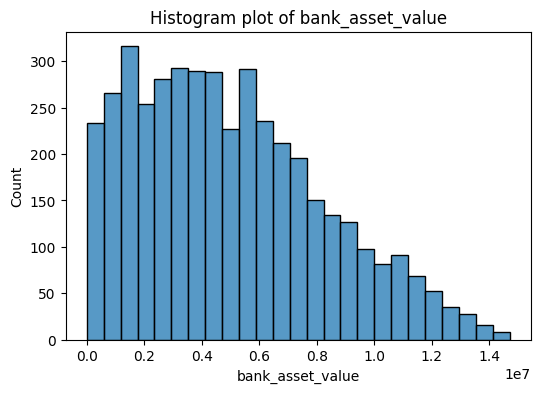

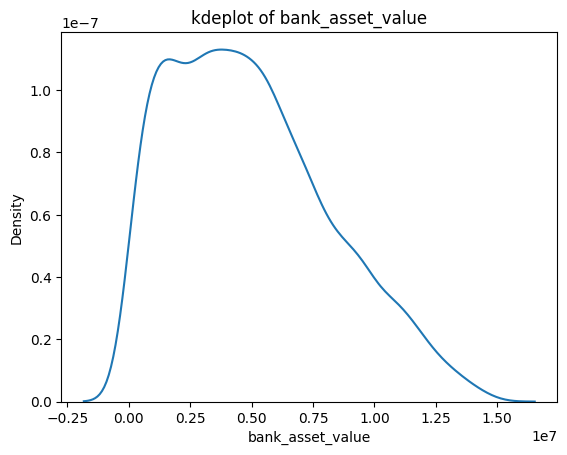

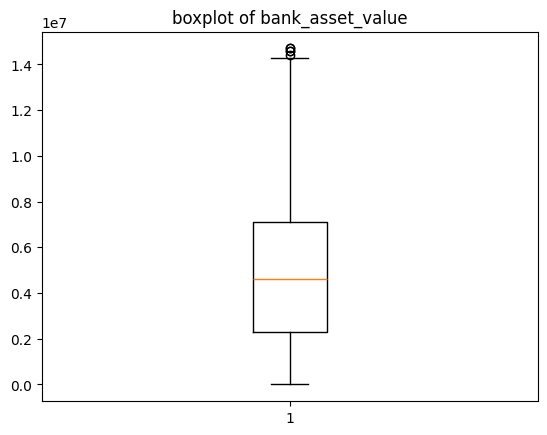

In [22]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:# numerical columns
        if col=='no_of_dependents' or col=='loan_term':
            continue
        plt.figure(figsize=(6,4))
        sns.histplot(df[col])
        plt.title(f'Histogram plot of {col}')
        plt.show()
        sns.kdeplot(df[col])
        plt.title(f'kdeplot of {col}')
        plt.show()
        plt.boxplot(df[col])
        plt.title(f'boxplot of {col}')
        plt.show()

## Insight:
### income_annum column:
*  The income_annum column appears almost uniformly distributed, with no strong peaks or skewness.
*  The boxplot indicates no significant outliers, suggesting the values are consistently spread across the range.
* Since the data is uniform and clean, income_annum is a stable feature.
* Further analysis is required to identify whethe it influence target column.
### loan_amount column:
* The distribution of data in loan_amount column shows fairly symmetricly.
* The box plot conclude that data is distributed across all region which conlcude that it had no outliers.
* Further bivariate analysis is required to identify whether it influence target column or not.
### cibil_score column:
* The data in cibil_score column is distributed uniformly between **(300-900)** means value are spread equally in all region.
* The boxplot shows that the data had not outliers value means no extreme value means value greater than **(900)** or nor small value means value smaller than **(300)** are present in data.
* Furthe bivariate analysis is required to identify whether it influecne target column or not.
### resisdential_assets column:
* The residential_assets column shows a right‑skewed distribution, meaning most values are concentrated at the lower end, with a long tail toward higher asset values.
* The boxplot reveals the presence of outliers, indicating that a few individuals hold exceptionally high residential asset values compared to the majority.
* This suggests that while most applicants have relatively modest residential assets, a small number of cases with very high values could distort statistical measures like the mean.
* Outliers may need to be handled (e.g., capping, removing) before modeling. Further bivariate analysis is required to assess whether residential assets influence the target variable (loan approval).
### commercial_assets column:
* The data is right skewed,outliers is present in data ,outliers must be handled before modeling
* Further bivariate analysis is required.
### luxury_assets column:
* The data is likely uniformly distributed,no outliers is present in data.
* Further bivariate analysis(stataistical or visualization analysis) is required.
### Bank_assets column:
* The data is likely normal distributed, some outlier value are present ,outliers need to hanlde before modeling.
* Bivariate analysis is required whether it influence target column or not.

## Handling outliers present in  residential_assets_value column 

In [23]:
q1=df['residential_assets_value'].quantile(0.25)

In [24]:
q3=df['residential_assets_value'].quantile(0.75)

In [25]:
q3

np.float64(11300000.0)

In [26]:
iqr=q3-q1

In [27]:
lower_value=q1-1.5*iqr
upper_value=q3+1.5*iqr

In [28]:
df['residential_assets_value']=np.where(df['residential_assets_value']>upper_value,upper_value,np.where(df['residential_assets_value']<lower_value,lower_value,df['residential_assets_value']))

In [29]:
df[(df['residential_assets_value']>upper_value)|(df['residential_assets_value']<lower_value)]

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status


## Handling outliers present commercial_assets_value column

In [30]:
q1=df['commercial_assets_value'].quantile(0.25)

In [31]:
q3=df['commercial_assets_value'].quantile(0.75)

In [32]:
iqr=q3-q1

In [33]:
lower_limit=q1-1.5*iqr
upper_limit=q3+1.5*iqr

In [34]:
df['commercial_assets_value']=np.where(df['commercial_assets_value']>upper_limit,upper_limit,np.where(df['commercial_assets_value']<lower_limit,
                                                                        lower_limit,df['commercial_assets_value']))

In [35]:
df[(df['commercial_assets_value']>upper_limit)|(df['commercial_assets_value']<lower_limit)]

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status


## Handling outliers present in bank_assets_value column

In [36]:
upper_limit=df['bank_asset_value'].mean()+3*df['bank_asset_value'].std()

In [37]:
lower_limit=df['bank_asset_value'].mean()-3*df['bank_asset_value'].std()

In [38]:
df['bank_asset_value']=np.where(df['bank_asset_value']>upper_limit,upper_limit,np.where(df['bank_asset_value']<lower_limit,lower_limit,df['bank_asset_value']))

In [39]:
df[(df['bank_asset_value']>upper_limit)|(df['bank_asset_value']<lower_limit)]

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status


## Performing Bivariate Analysis

## no_of_dependents and loan_status column analysis together

In [40]:
result=pd.crosstab(df['loan_status'],df['no_of_dependents'])
result

no_of_dependents,0,1,2,3,4,5
loan_status,,,,,,
Approved,457,430,441,457,465,406
Rejected,255,267,267,270,287,267


<Axes: xlabel='no_of_dependents', ylabel='loan_status'>

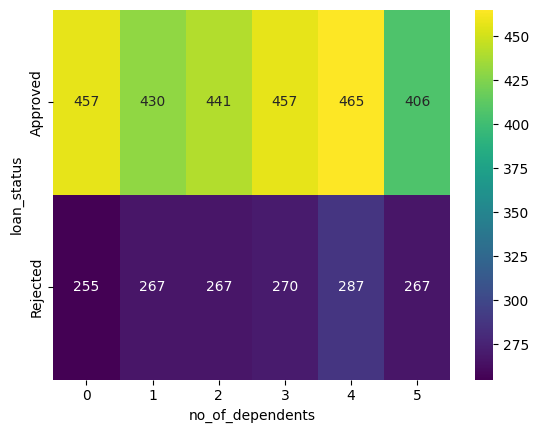

In [41]:
sns.heatmap(result,annot=True,cmap='viridis',fmt='d')

<Figure size 800x800 with 0 Axes>

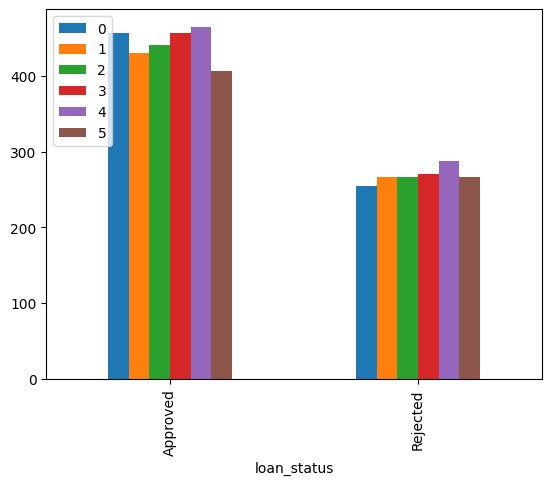

In [42]:
plt.figure(figsize=(8,8))
result.plot(kind='bar')
plt.legend(loc='upper left')
plt.show()

In [43]:
##H0:There is no significant between number_of_dependent and approval column
##H1:There is significant differnce between number_of_dependent and approval column

In [44]:
from scipy.stats import chi2_contingency

In [45]:
chi_square,p_value,dof,expected_value=chi2_contingency(result)
print(chi_square,p_value,dof,expected_value)
alpha=0.05
if p_value<alpha:
    print('Reject H0')
else:
    print('Fail to reject H0')
     

2.454183890937016 0.7833787033887646 5 [[442.97774654 433.6453502  440.48910752 452.31014289 467.8641368
  418.71351605]
 [269.02225346 263.3546498  267.51089248 274.68985711 284.1358632
  254.28648395]]
Fail to reject H0


## Insight:
* From the Chi‑Square statistical test, we found that the no_of_dependents column has no significant effect on the target column (loan_status).
* This means the number of dependents does not show a strong association with loan approval outcomes.
* We can conclude that no_of_dependents is not a strong predictor for the target variable in this dataset.
  

## education and loan_status column analysis together

In [46]:
result=pd.crosstab(df['loan_status'],df['education'])
result

education,Graduate,Not Graduate
loan_status,,
Approved,1339,1317
Rejected,805,808


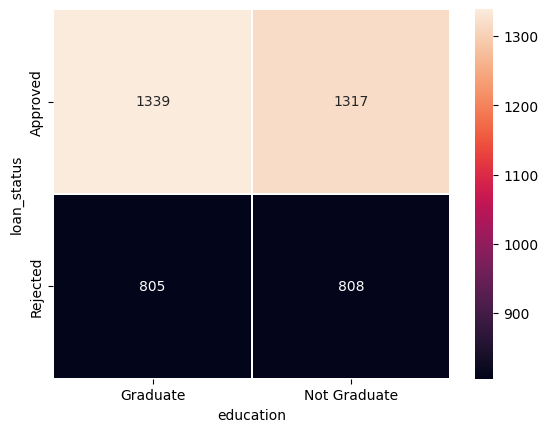

In [47]:
sns.heatmap(result,annot=True,linewidth=0.2,fmt='d')
plt.show()

In [48]:
# Chi_square independence test to identify whether eucation column are important factor for target column or not
#H0:There is no significant differnce between education and target column(loan_status).
#H1:There is significatn diffence between education and target column.
chi_square,p_value,dof,expected_value=chi2_contingency(result)
if p_value<0.05:
    print('Reject H0')
else:
    print('Fail to Reject H0')

Fail to Reject H0


## Insight:
* From chi_square test,we conclude that there is no significant differnce or assocation between eucation and target column(loadn_status).
* This mean that education does not strong assocation with target column like commercial_assets_value,creditscore etc.
* Education are not important predicator for target column. 

## self_employed and loan_approval column analysis together

In [49]:
result=pd.crosstab(df['loan_status'],df['self_employed'])
result

self_employed,No,Yes
loan_status,,
Approved,1318,1338
Rejected,801,812


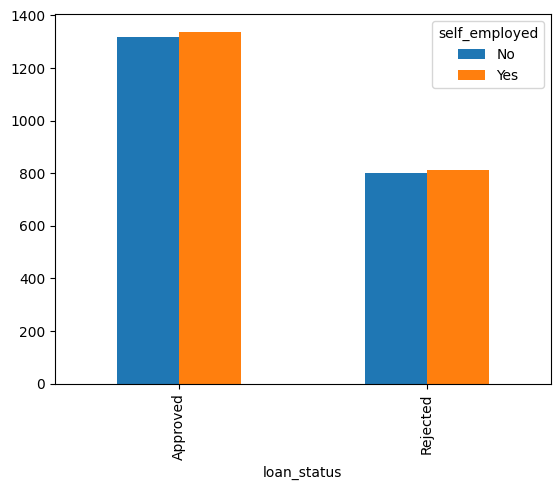

In [50]:
result.plot(kind='bar')
plt.show()

In [51]:
##H0:There is no assocation between eudcation and approval_status column
##H1:There is assocation between education and approval_status column
chi_square,p_value,dof,expected_value=chi2_contingency(result)
if p_value<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')

Fail to reject H0


## Insight:
* We can clearly see from chi_square statistics test self_employed column is not strong factor for prediciting loan_status.
* But it was little surprising that self_employed column also had not affect on target column.

In [52]:
df.sample()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
3580,3,Graduate,Yes,3100000,11200000,14,772,3400000.0,5800000.0,8300000,2100000.0,Approved


## income_annum and loan_status column analysis together

In [53]:
df.groupby('loan_status')['income_annum'].mean()

loan_status
Approved    5.025904e+06
Rejected    5.113825e+06
Name: income_annum, dtype: float64

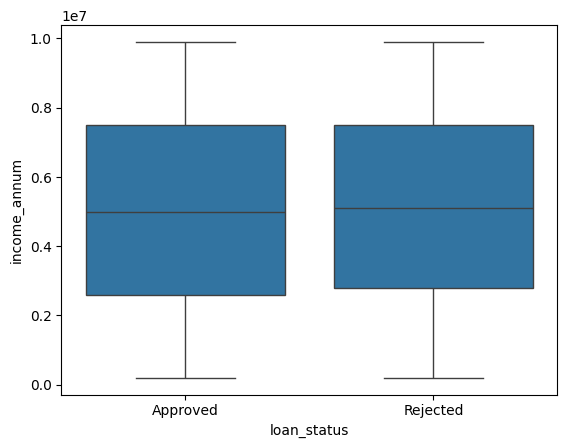

In [54]:
sns.boxplot(data=df,x='loan_status',y='income_annum')
plt.show()

In [55]:
from scipy.stats import ttest_ind

In [56]:
##H0:There is no assocation between targert column and input column(income_annum)
##H1:There is assocation between target column and input column(income_annum)
approved=df[df['loan_status']=='Approved']['income_annum']
rejected=df[df['loan_status']=='Rejected']['income_annum']
t_value,p_value=ttest_ind(approved,rejected)
if p_value<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')

Fail to reject H0


## Insight:
* Using ttest_ind we can clearly see that there is no significant relation between input column(income_annum) and target column(loan_status).
* We can conclude that income_annum is not important factor for predicting loan_stats.

## loan_amount and loan_status column analysis together

<Axes: xlabel='loan_status', ylabel='loan_amount'>

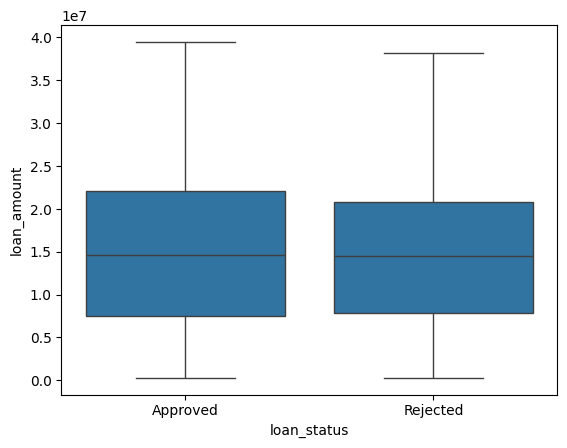

In [57]:
sns.boxplot(data=df,x='loan_status',y='loan_amount')

In [58]:
##H0:There is no significant differnce between loan_amount and loan_status column
##H1:Ther is significant differnce between loan_amount and loan_status column
approved_income=df[df['loan_status']=='Accepted']['loan_amount']
reject_income=df[df['loan_status']=='Rejected']['loan_amount']
t_test,p_value=ttest_ind(approved_income,reject_income)
if p_value<0.05:
    print('Reject H0')
else:
    print('Faill to reject H0')

Faill to reject H0


C:\Users\jitenshah\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


## Insight:
* loan_amount column is also not important factor for predicting loan_status column.

## loan_term and loan_status column analysis together

In [59]:
result=pd.crosstab(df['loan_status'],df['loan_term'])
result

loan_term,2,4,6,8,10,12,14,16,18,20
loan_status,,,,,,,,,,
Approved,315,366,282,220,229,276,239,236,257,236
Rejected,89,81,208,166,207,180,166,176,165,175


<Axes: xlabel='loan_term', ylabel='loan_status'>

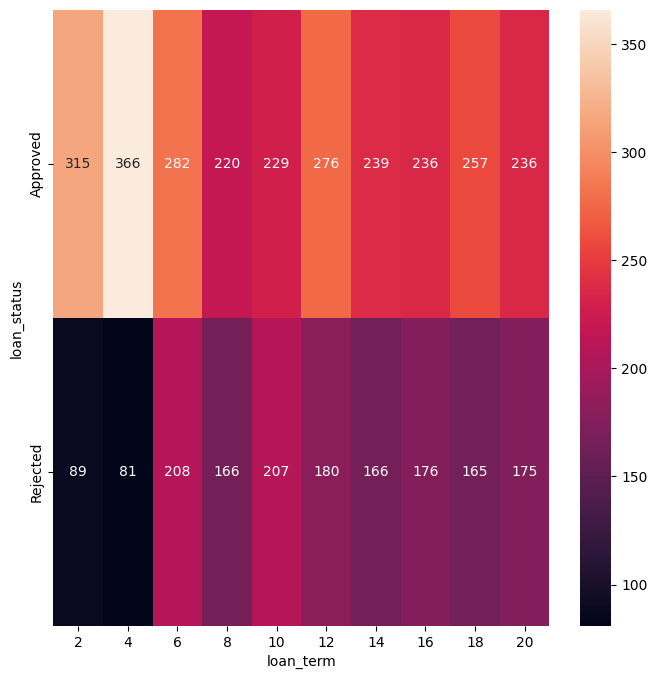

In [60]:
plt.figure(figsize=(8,8))
sns.heatmap(result,annot=True,fmt='d')

In [61]:
##H0:There is no association between input column(loan_term) and target column(loan_status).
##H1:There is association between input column and target column
chi_value,p_value,dof,expected_value=chi2_contingency(result)
if p_value<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')

Reject H0


## Insight:
* From chi_square independence test,we have clearly see that loan_term and loan_status arre asscoiate with each other.
* We can conclude that loan_term input column is an important factor for predicting loan_status

## cibil_score and loan_status column analysis together

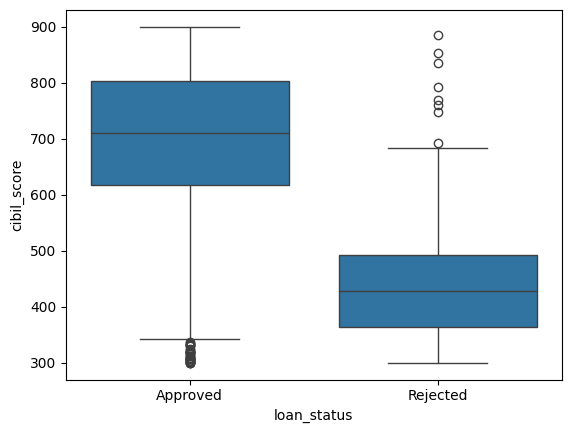

In [62]:
sns.boxplot(data=df,x='loan_status',y='cibil_score')
plt.show()

In [63]:
approved_creditscore=df[df['loan_status']=='Approved']['cibil_score']
reject_creditscore=df[df['loan_status']=='Rejected']['cibil_score']

In [64]:
t_test,p_value=ttest_ind(approved_creditscore,reject_creditscore)
if p_value<0.05:
    print('Reject H0')
else:
    print('Accept H0')

Reject H0


## Insight:
* The distribution of cibil_score differs noticeably between the Approved and Rejected categories, suggesting that loan approval outcomes vary with credit score levels.
* A two‑sample independent t-test confirms this difference is statistically significant (p < 0.05), reinforcing the visual evidence.
* cibil_score emerges as a strong predictor of the target variable (loan_status), meaning applicants with higher scores are more likely to be approved.

## residential_assets_value and loan_status analysis together

<Axes: xlabel='loan_status', ylabel='residential_assets_value'>

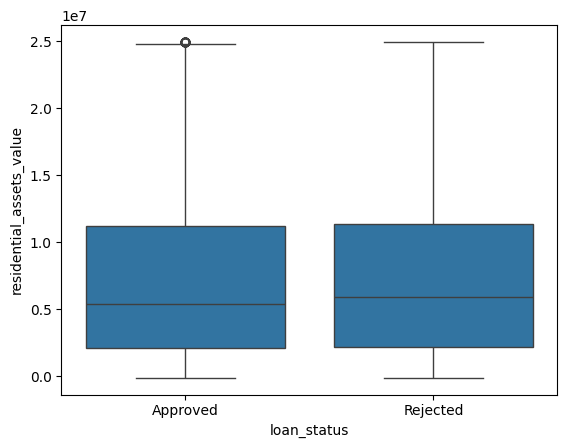

In [65]:
sns.boxplot(data=df,x='loan_status',y='residential_assets_value')

In [66]:
approved_assets = df[df['loan_status'] == 'Approved']['residential_assets_value']
rejected_assets = df[df['loan_status'] == 'Rejected']['residential_assets_value']
t_value, p_value = ttest_ind(approved_assets, rejected_assets)
if p_value < 0.05:
    print("Reject H0: Residential asset values differ significantly between approved and rejected groups.")
else:
    print("Fail to reject H0: No significant difference in residential asset values.")

Fail to reject H0: No significant difference in residential asset values.


## Insight:
* We have conclude that resisdential_assets_value is not an important for predicting loan_status column,which show that having more residentail_assets_value are more likely to get the loan.

## commercial_asset_value and loan_status column analysis together

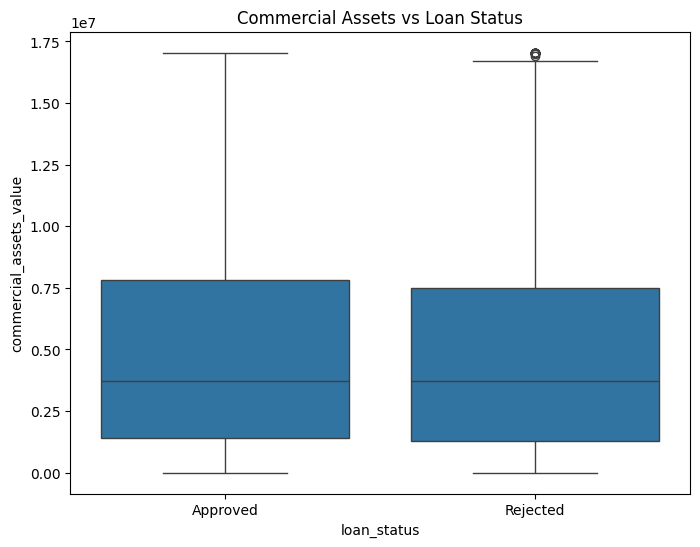

In [67]:
plt.figure(figsize=(8,6))
sns.boxplot(x='loan_status', y='commercial_assets_value', data=df)
plt.title('Commercial Assets vs Loan Status')
plt.show()

In [68]:
approved_assets = df[df['loan_status'] == 'Approved']['commercial_assets_value']
rejected_assets = df[df['loan_status'] == 'Rejected']['commercial_assets_value']


t_value, p_value = ttest_ind(approved_assets, rejected_assets, equal_var=False)

print(f"T-statistic: {t_value:.3f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Commercial asset values differ significantly between approved and rejected groups.")
else:
    print("Fail to reject H0: No significant difference in commercial asset values.")

T-statistic: 0.575, P-value: 0.5651
Fail to reject H0: No significant difference in commercial asset values.


## Insight:
* We have verified that commercial_assets_value is not an important factor for predicting loan_statu column using visualize and statistics ttest_ind technique.

## luxury_assets_value and  loan_status column analysis together

<Axes: xlabel='loan_status', ylabel='luxury_assets_value'>

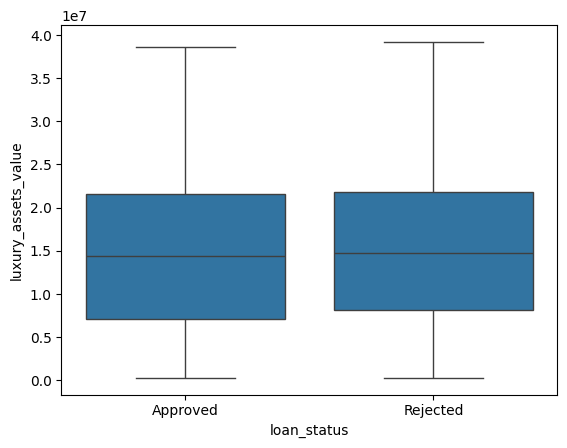

In [69]:
sns.boxplot(data=df,y='luxury_assets_value',x='loan_status')

In [70]:
approved_luxury = df[df['loan_status'] == 'Approved']['luxury_assets_value']
rejected_luxury = df[df['loan_status'] == 'Rejected']['luxury_assets_value']

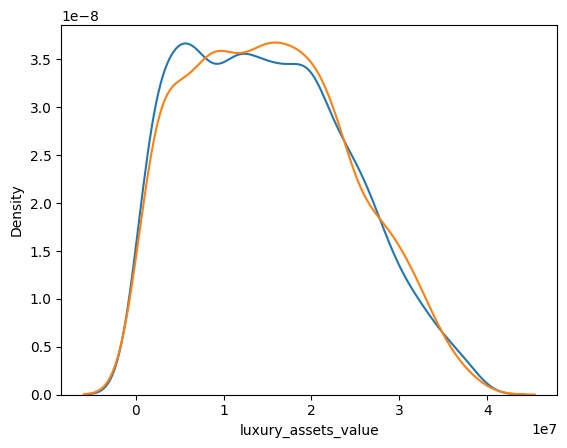

In [73]:
sns.kdeplot(approved_luxury)
sns.kdeplot(rejected_luxury)
plt.show()

In [74]:
t_value, p_value = ttest_ind(approved_luxury, rejected_luxury)

print(f"T-statistic: {t_value:.3f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Luxury asset values differ significantly between approved and rejected groups.")
else:
    print("Fail to reject H0: No significant difference in luxury asset values.")

T-statistic: -1.010, P-value: 0.3124
Fail to reject H0: No significant difference in luxury asset values.


## Insight:
* Using visualization and statistics t-test techniuqe we have conlcude that luxury_asset is not an important factor for predicting target columnw with was surprising to me.

## bank_asset_value and loan_status column analysis together

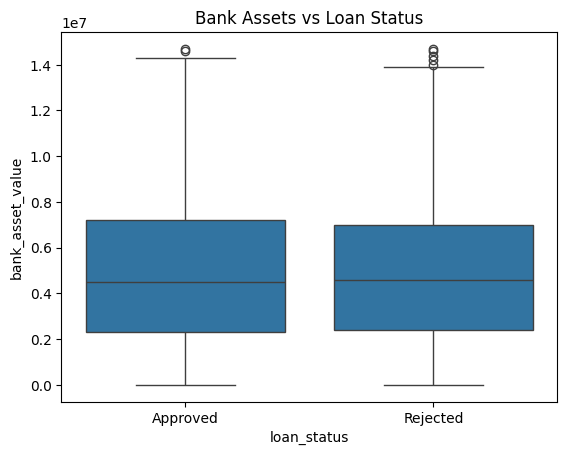

In [75]:
sns.boxplot(x='loan_status', y='bank_asset_value', data=df)
plt.title('Bank Assets vs Loan Status')
plt.show()

In [76]:
approved_bank = df[df['loan_status'] == 'Approved']['bank_asset_value']
rejected_bank = df[df['loan_status'] == 'Rejected']['bank_asset_value']

t_bank, p_bank = ttest_ind(approved_bank, rejected_bank, equal_var=False)
print(f"Bank Assets → T={t_bank:.3f}, P={p_bank:.4f}")
if p_bank < 0.05:
    print("Reject H0: Significant difference in bank asset values.")
else:
    print("Fail to reject H0: No significant difference in bank asset values.")

Bank Assets → T=-0.445, P=0.6564
Fail to reject H0: No significant difference in bank asset values.


## Insight:
* t-test results (p = 0.6564) show no significant difference in bank asset values between Approved and Rejected applicants, meaning this variable is not an important factor for loan approval compared to stronger predictors like cibil_score.

## Multivariate Analysis

## Checking correlation among numerical column.

In [89]:
result=df[['income_annum','loan_amount','cibil_score','residential_assets_value','commercial_assets_value','luxury_assets_value','bank_asset_value']].corr()

plt.figure(figsize=(8,8))
sns.heatmap(result,annot=True)
plt.title('Correlation of Numerical Column')
plt.show()

## Insight:
* bank_asset_value,income_annum,loan_amount,resisdential_assets_value,commercial_assets_value,luxury_assets_value columns are correlated with each other i.e., it will create multicollinearity problem.
* We will perfrom feature engineering by combining (bank_asset_value,resisdential_assets_value,commercial_assets,value luxury_assets_value as a single column as total_asset_value) to prevent from multicollineaity.

## using pairplot to see how each numerical column are related with each other.

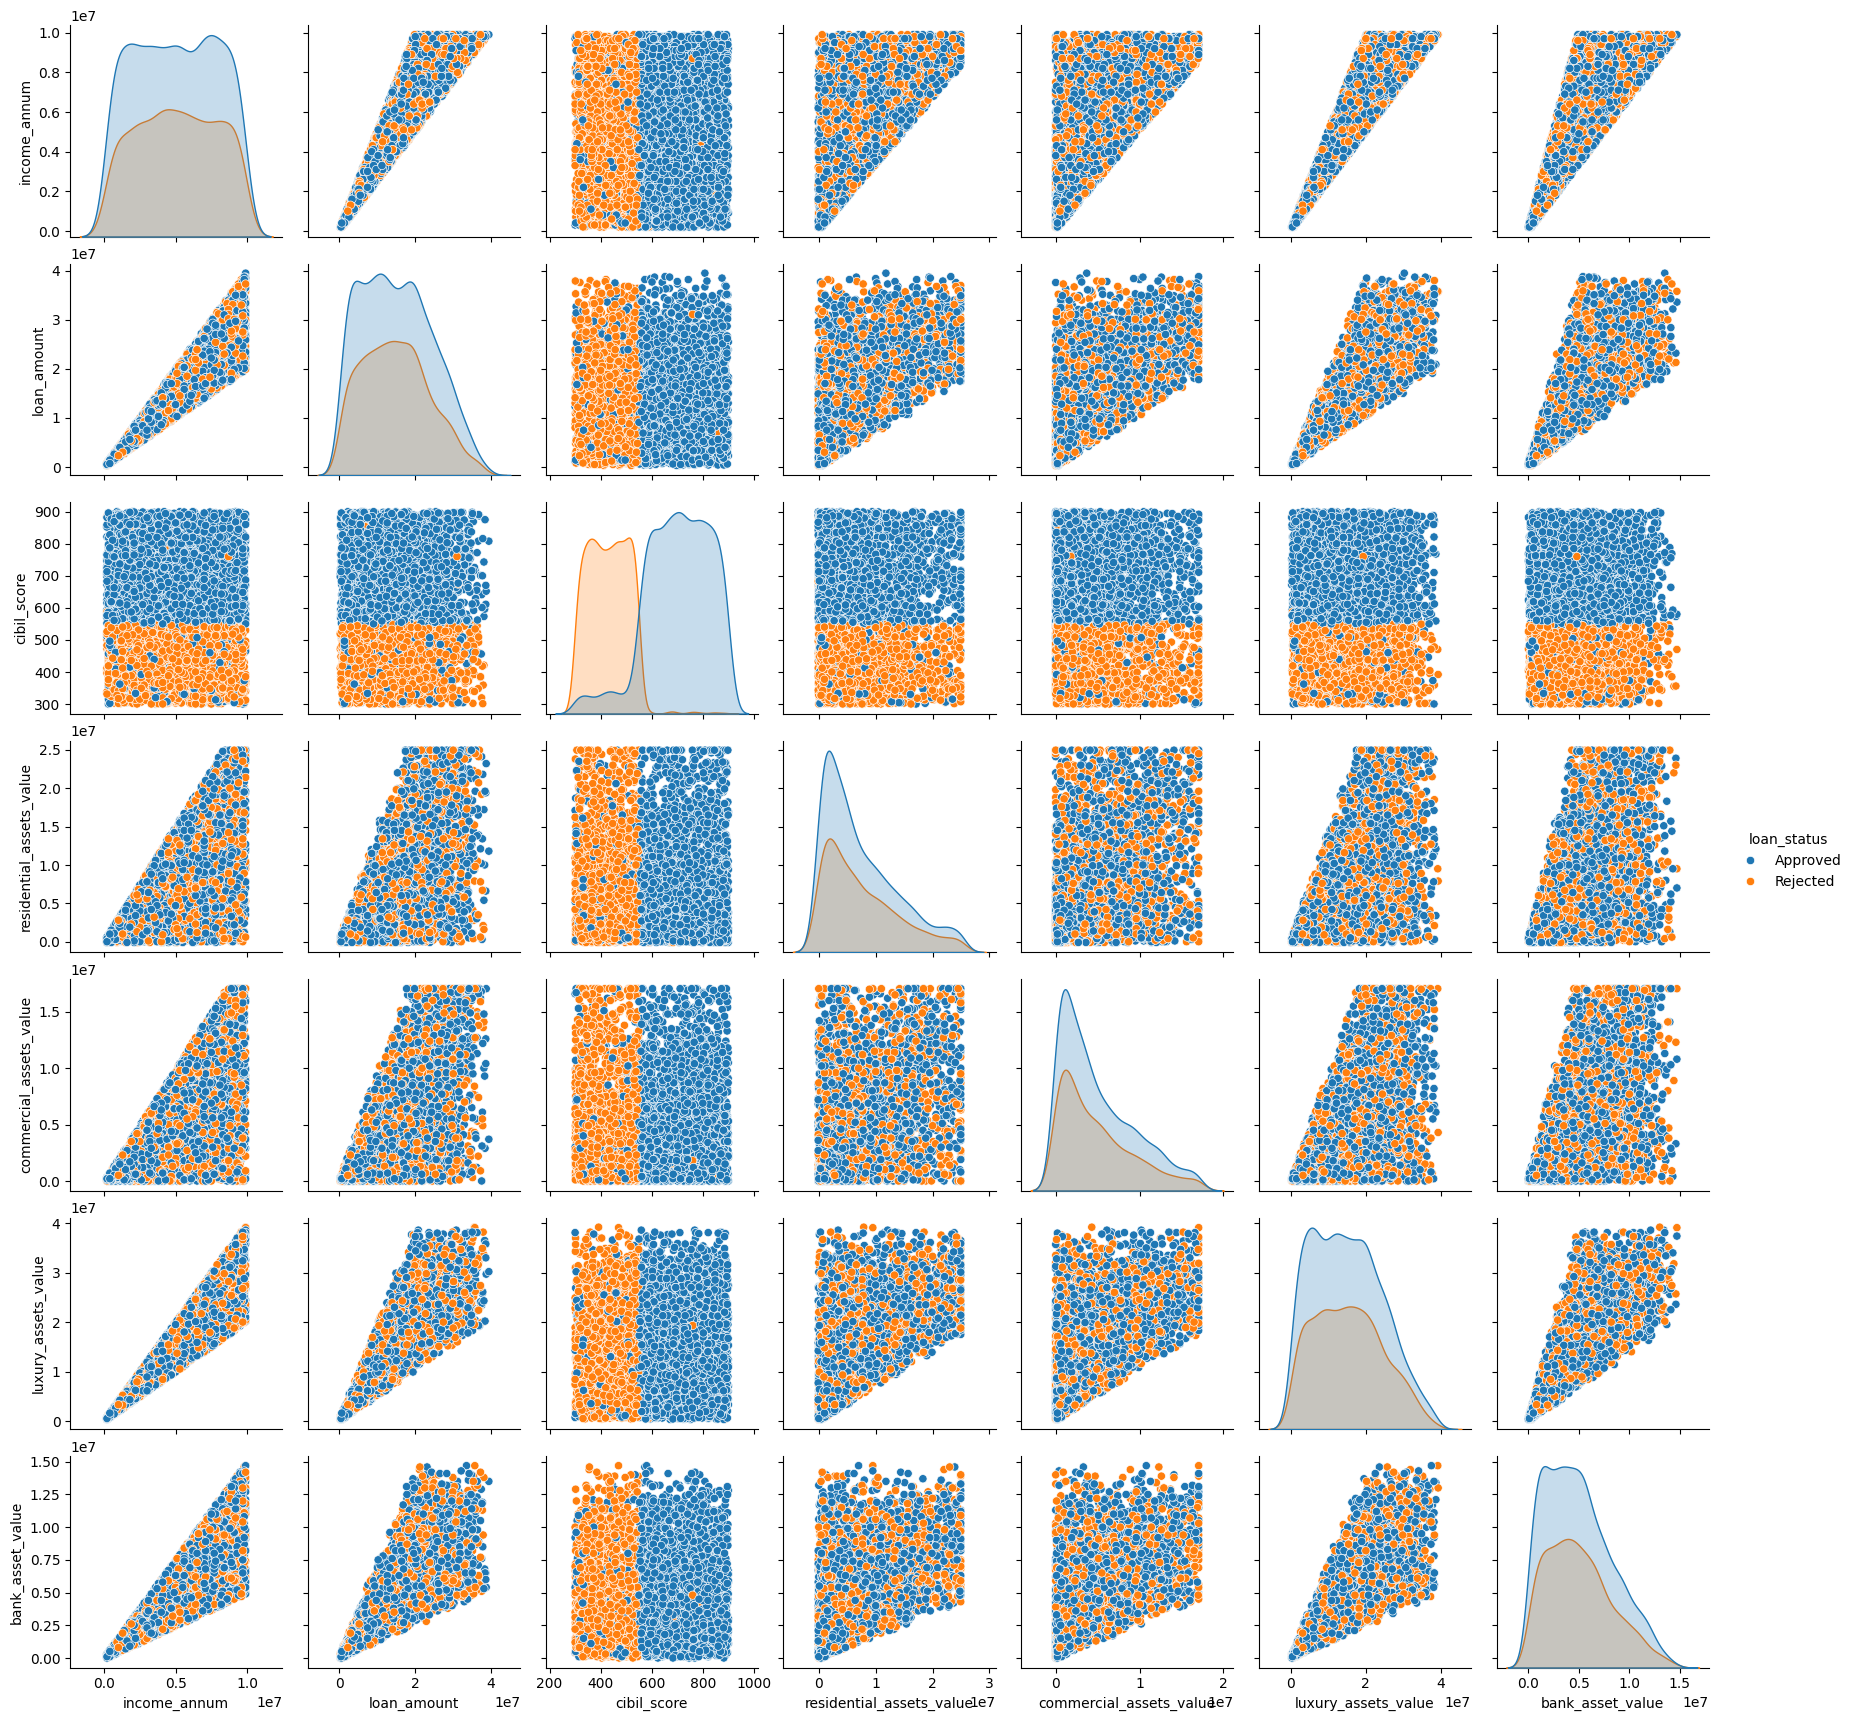

In [95]:
temp=df.drop(columns=['no_of_dependents','loan_term'],axis=1)
sns.pairplot(temp,hue='loan_status')
plt.show()

## Insight:
* From pairplot also we can clearly see that many numerical column are correlated with each other that will create the problem of multicollinearity.
* If we are using a model like logistic regression then it will create problem,we should handle it create carefully.

## Now we have complete our EDA part,we are ready to build our model.

In [96]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [70]:
X=df.drop(columns=['loan_status'])
y=df['loan_status']

In [71]:
X['total_assets_value']=X['residential_assets_value']+X['commercial_assets_value']+X['luxury_assets_value']+X['bank_asset_value']

In [72]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [73]:
le=LabelEncoder()
y_train_scale=le.fit_transform(y_train)
y_test_scale=le.transform(y_test)

In [74]:
numerical_features=['income_annum','loan_amount','cibil_score','total_assets_value']
categorial_features=['education','self_employed']
columns_to_leave=['no_of_dependents','loan_term']

In [98]:
preprocessor=ColumnTransformer(transformers=[
    ('numeric',StandardScaler(),numerical_features),
    ('leave','passthrough',columns_to_leave),
    ('categoric',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),categorial_features),
],remainder='drop')

In [99]:
pipe=Pipeline([
    ('preprocessing',preprocessor),
    ('classifier',LogisticRegression(max_iter=100,random_state=42))])

In [100]:
pipe.fit(x_train,y_train_scale)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('leave', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [101]:
pipe=Pipeline([
    ('preprocessing',preprocessor),
    ('classifier',SVC(kernel='rbf',C=10,gamma='auto',probability=True))])
    

In [102]:
pipe.fit(x_train,y_train_scale)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('leave', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [103]:
y_pred=pipe.predict(x_test)

In [104]:
accuracy_score(y_test_scale,y_pred)

0.9508196721311475

In [105]:
precision_score(y_test_scale,y_pred)

0.9451612903225807

In [106]:
recall_score(y_test_scale,y_pred)

0.9213836477987422

In [107]:
result=confusion_matrix(y_test_scale,y_pred)

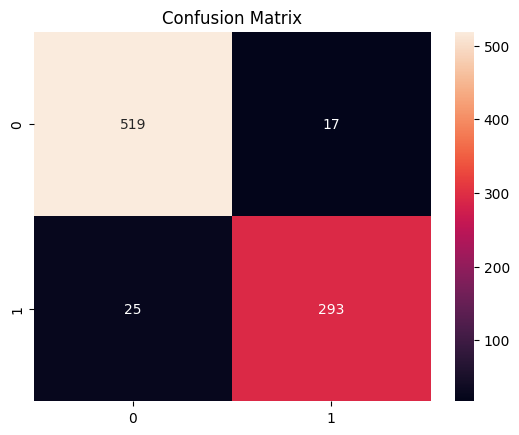

In [108]:
sns.heatmap(result,annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.show()

In [109]:
with open('classifier.pkl','wb') as f:
    pickle.dump(pipe,f)